<a href="https://colab.research.google.com/github/xavierjacomep/curso-intro-machine-learning/blob/main/02_validacion_cruzada_comparacion_modelos_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#0F172A; padding:36px 48px;">
  <h1 style="color:#FFFFFF; font-size:2em; margin:0; font-weight:800; letter-spacing:1px;">
    🔁 VALIDACIÓN CRUZADA Y COMPARACIÓN DE MODELOS
  </h1>
  <h2 style="color:#38BDF8; font-size:1.1em; margin:12px 0 6px 0; font-weight:400;">
    Caso Práctico: Valoración de Bienes Raíces (Sindian Dist., New Taipei City, Taiwán)
  </h2>
  <p style="color:#94A3B8; margin:0; font-size:0.95em;">
    Notebook 2 de 3 — Nivel: INTERMEDIO · Validación cruzada + segundo algoritmo (no lineal)
  </p>
</div>

---
## 🎯 Objetivo de este notebook

En el Notebook 1 evaluamos un modelo lineal con **una sola división train/test**. El problema:
el resultado depende de qué observaciones cayeron, por azar, en el conjunto de test.

En este notebook:
1. Repetimos el pipeline base (carga, limpieza, split) de forma resumida.
2. Introducimos **validación cruzada K-Fold**, para obtener una estimación más robusta del error.
3. Agregamos un **segundo algoritmo** — Random Forest Regressor — capaz de capturar relaciones
   no lineales entre las variables y el precio.
4. Comparamos ambos modelos usando las métricas de regresión, y justificamos cuál metrica
   usar como criterio de decisión.

---
## 📦 Paso 0 — Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score, make_scorer
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

print("✅ Librerías importadas")

✅ Librerías importadas


---
## 📂 Paso 1 — Cargar datos y pipeline base

Repetimos la carga y preparación mínima del notebook anterior. Este es el punto de partida:
datos limpios, sin ninguna técnica adicional de *feature engineering* todavía (eso lo veremos
en el Notebook 3).

In [2]:
!pip install -q ucimlrepo
from ucimlrepo import fetch_ucirepo

real_estate = fetch_ucirepo(id=477)
df = pd.concat([real_estate.data.features, real_estate.data.targets], axis=1)

FEATURES = [
    'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station',
    'X4 number of convenience stores', 'X5 latitude', 'X6 longitude'
]
TARGET = 'Y house price of unit area'

X = df[FEATURES]
y = df[TARGET]

print(f"Filas: {df.shape[0]}  |  Nulos totales: {df.isnull().sum().sum()}  |  Duplicados: {df.duplicated().sum()}")
df.head()

Filas: 414  |  Nulos totales: 0  |  Duplicados: 0


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
# Split de referencia (el mismo del Notebook 1), lo mantenemos para comparar
# "1 fold" vs "validación cruzada"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_lr_single = LinearRegression()
modelo_lr_single.fit(X_train_scaled, y_train)
y_pred_single = modelo_lr_single.predict(X_test_scaled)

def calcular_metricas(y_true, y_pred, n_features):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    n    = len(y_true)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'R2_adj': r2_adj}

metricas_single = calcular_metricas(y_test, y_pred_single, len(FEATURES))
print("Métricas — 1 solo split (Regresión Lineal):")
for k, v in metricas_single.items():
    print(f"  {k:8s}: {v:.4f}")

Métricas — 1 solo split (Regresión Lineal):
  MAE     : 5.3054
  MSE     : 53.5056
  RMSE    : 7.3148
  MAPE    : 17.1825
  R2      : 0.6811
  R2_adj  : 0.6559


---
## 🔁 Paso 2 — Validación Cruzada (K-Fold)

### El problema con un solo split

En el Notebook 1 dividimos los datos **una sola vez**: 80% train, 20% test. El RMSE que
obtuvimos depende de qué 83 transacciones (20% de 414) cayeron por azar en el test.
Si otra partición hubiera dejado afuera casas particularmente caras o baratas, el RMSE habría
sido distinto.

### La solución

**K-Fold Cross-Validation** divide los datos en *K* partes (folds). El modelo se entrena *K*
veces, usando cada vez una parte distinta como test y las demás como train. Al final,
promediamos el resultado de los *K* folds → una estimación mucho más **estable y confiable**
del desempeño real del modelo.

> A diferencia de clasificación, aquí usamos `KFold` (no `StratifiedKFold`), porque no hay
> clases que estratificar — `y` es continua.

In [4]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def r2_ajustado_func(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

def hacer_scoring(n_features):
    # Definimos una función interna (closure) en vez de functools.partial: versiones
    # recientes de scikit-learn (>=1.6) construyen un repr() de cada scorer al validar el
    # diccionario de scoring, y ese repr() falla con un AttributeError si el score_func es
    # un functools.partial (no tiene atributo __name__). Una función normal definida con
    # `def` sí tiene __name__, así que evitamos el problema por completo.
    def r2_ajustado_scorer(y_true, y_pred):
        return r2_ajustado_func(y_true, y_pred, n_features=n_features)

    return {
        'MAE':    'neg_mean_absolute_error',
        'RMSE':   'neg_root_mean_squared_error',
        'MAPE':   'neg_mean_absolute_percentage_error',
        'R2':     'r2',
        'R2_adj': make_scorer(r2_ajustado_scorer)
    }

scoring = hacer_scoring(n_features=len(FEATURES))

# ⚠️ IMPORTANTE: usamos un Pipeline (escalador + modelo) en vez de escalar X una sola vez
# antes de la validación cruzada. Si escalamos con StandardScaler().fit_transform(X) ANTES
# de entrar a cross_validate, la media/desviación estándar de CADA fold de validación ya
# estarían "contaminando" el ajuste del escalador (se calculan usando también esos datos
# que deberían ser desconocidos para ese fold) — esto es fuga de datos (data leakage).
# Con un Pipeline, cross_validate clona el pipeline en cada fold y el `fit` del scaler
# ocurre SOLO con los datos de entrenamiento de ese fold.
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LinearRegression())
])

resultados_lr_cv = cross_validate(
    pipeline_lr, X, y,
    cv=kfold, scoring=scoring, return_train_score=False
)

mae_cv    = -resultados_lr_cv['test_MAE']
rmse_cv   = -resultados_lr_cv['test_RMSE']
mape_cv   = -resultados_lr_cv['test_MAPE'] * 100
r2_cv     = resultados_lr_cv['test_R2']
r2_adj_cv = resultados_lr_cv['test_R2_adj']

print("Resultados por fold — Regresión Lineal:")
print(f"  MAE  por fold : {np.round(mae_cv, 2)}")
print(f"  RMSE por fold : {np.round(rmse_cv, 2)}")
print(f"  R²   por fold : {np.round(r2_cv, 3)}")
print()
print(f"  MAE         promedio : {mae_cv.mean():.3f}  (± {mae_cv.std():.3f})")
print(f"  RMSE        promedio : {rmse_cv.mean():.3f}  (± {rmse_cv.std():.3f})")
print(f"  MAPE        promedio : {mape_cv.mean():.2f}%  (± {mape_cv.std():.2f})")
print(f"  R²          promedio : {r2_cv.mean():.4f}  (± {r2_cv.std():.4f})")
print(f"  R² ajustado promedio : {r2_adj_cv.mean():.4f}  (± {r2_adj_cv.std():.4f})")

Resultados por fold — Regresión Lineal:
  MAE  por fold : [5.31 6.11 6.28 6.53 6.87]
  RMSE por fold : [ 7.31  8.6   8.22  8.58 11.26]
  R²   por fold : [0.681 0.437 0.633 0.606 0.49 ]

  MAE         promedio : 6.220  (± 0.523)
  RMSE        promedio : 8.796  (± 1.316)
  MAPE        promedio : 18.94%  (± 1.51)
  R²          promedio : 0.5693  (± 0.0914)
  R² ajustado promedio : 0.5352  (± 0.0987)


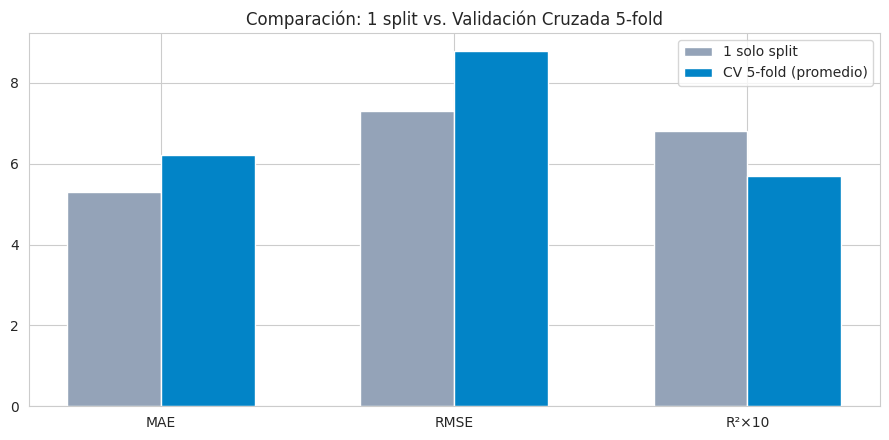

In [5]:
# Comparación visual: 1 fold original vs validación cruzada 5-fold
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(3)
ancho = 0.32
nombres = ['MAE', 'RMSE', 'R²×10']  # R² escalado x10 solo para visualizar en la misma escala

valores_single = [metricas_single['MAE'], metricas_single['RMSE'], metricas_single['R2'] * 10]
valores_cv      = [mae_cv.mean(), rmse_cv.mean(), r2_cv.mean() * 10]

ax.bar(x - ancho/2, valores_single, ancho, label='1 solo split', color='#94A3B8')
ax.bar(x + ancho/2, valores_cv, ancho, label='CV 5-fold (promedio)', color='#0284C7')
ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_title('Comparación: 1 split vs. Validación Cruzada 5-fold')
ax.legend()

plt.tight_layout()
plt.show()

### 📌 Conclusión: ¿cuándo usar cada uno?

| Situación | Usa |
|---|---|
| Quieres una estimación **confiable** del desempeño real del modelo | ✅ Validación cruzada |
| Necesitas **comparar** dos o más modelos de forma justa | ✅ Validación cruzada |
| Estás iterando muy rápido en la fase exploratoria y el dataset es enorme | 1 split es aceptable como primera aproximación |
| Vas a reportar el desempeño final de tu modelo elegido | ✅ Validación cruzada (o un holdout final separado desde el inicio) |

---
## 🌳 Paso 3 — Segundo algoritmo: Random Forest Regressor

La Regresión Lineal asume una relación **lineal** entre cada variable y el precio. Pero,
por ejemplo, la relación entre `X3 distance to the nearest MRT station` y el precio podría no
ser una línea recta (el efecto de estar muy cerca del metro podría ser desproporcionadamente
alto comparado con estar a una distancia intermedia).

**Random Forest** es un modelo de conjunto (*ensemble*) basado en muchos árboles de decisión,
capaz de capturar relaciones **no lineales** e interacciones entre variables, sin que tengamos
que especificarlas manualmente.

> Nota: los modelos basados en árboles no *requieren* escalado de variables (son invariantes
> a la escala), pero lo mantenemos aquí (dentro de un `Pipeline`) para que la comparación sea
> idéntica entre ambos modelos, y para practicar el patrón correcto de escalar **dentro** de
> cada fold de la validación cruzada.

In [6]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE))
])

resultados_rf_cv = cross_validate(
    pipeline_rf, X, y,
    cv=kfold, scoring=scoring, return_train_score=False
)

mae_rf    = -resultados_rf_cv['test_MAE']
rmse_rf   = -resultados_rf_cv['test_RMSE']
mape_rf   = -resultados_rf_cv['test_MAPE'] * 100
r2_rf     = resultados_rf_cv['test_R2']
r2_adj_rf = resultados_rf_cv['test_R2_adj']

print("Resultados por fold — Random Forest:")
print(f"  MAE         promedio : {mae_rf.mean():.3f}  (± {mae_rf.std():.3f})")
print(f"  RMSE        promedio : {rmse_rf.mean():.3f}  (± {rmse_rf.std():.3f})")
print(f"  MAPE        promedio : {mape_rf.mean():.2f}%  (± {mape_rf.std():.2f})")
print(f"  R²          promedio : {r2_rf.mean():.4f}  (± {r2_rf.std():.4f})")
print(f"  R² ajustado promedio : {r2_adj_rf.mean():.4f}  (± {r2_adj_rf.std():.4f})")

Resultados por fold — Random Forest:
  MAE         promedio : 4.676  (± 0.417)
  RMSE        promedio : 7.260  (± 1.372)
  MAPE        promedio : 13.27%  (± 1.79)
  R²          promedio : 0.7066  (± 0.0759)
  R² ajustado promedio : 0.6833  (± 0.0820)


---
## 📊 Paso 4 — Comparación de modelos (todas las métricas)

Ahora construimos una tabla comparativa con **ambos** modelos, usando siempre validación
cruzada 5-fold para que la comparación sea justa.

In [7]:
tabla_comparativa = pd.DataFrame({
    'Regresión Lineal': {
        'MAE': mae_cv.mean(), 'RMSE': rmse_cv.mean(), 'MAPE': mape_cv.mean(),
        'R²': r2_cv.mean(), 'R² ajustado': r2_adj_cv.mean()
    },
    'Random Forest': {
        'MAE': mae_rf.mean(), 'RMSE': rmse_rf.mean(), 'MAPE': mape_rf.mean(),
        'R²': r2_rf.mean(), 'R² ajustado': r2_adj_rf.mean()
    }
}).T

tabla_comparativa.round(4)

,MAE,RMSE,MAPE,R²,R² ajustado
Regresión Lineal,6.2198,8.7961,18.9446,0.5693,0.5352
Random Forest,4.6756,7.2596,13.2711,0.7066,0.6833


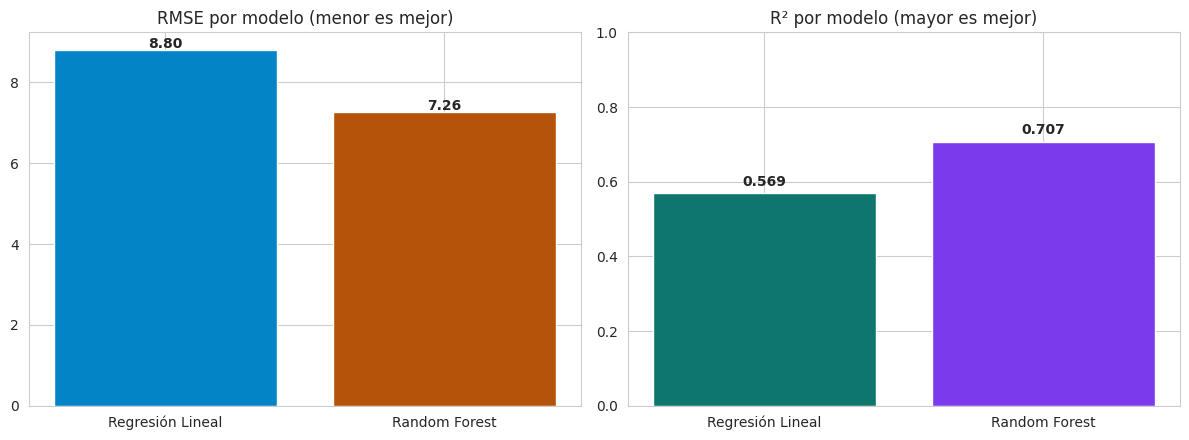

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

modelos_nombres = tabla_comparativa.index.tolist()

axes[0].bar(modelos_nombres, tabla_comparativa['RMSE'], color=['#0284C7', '#B45309'])
axes[0].set_title('RMSE por modelo (menor es mejor)')
for i, v in enumerate(tabla_comparativa['RMSE']):
    axes[0].text(i, v + 0.05, f"{v:.2f}", ha='center', fontweight='bold')

axes[1].bar(modelos_nombres, tabla_comparativa['R²'], color=['#0F766E', '#7C3AED'])
axes[1].set_title('R² por modelo (mayor es mejor)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(tabla_comparativa['R²']):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## ⭐ Paso 5 — ¿Qué métrica usamos para decidir el mejor modelo?

Podríamos elegir el "mejor" modelo mirando MAE, RMSE, MAPE o R² — y no siempre están de
acuerdo. Para **este caso de negocio** (valoración inmobiliaria), usamos **RMSE** como
criterio principal de decisión, porque:

- Está en las mismas unidades que el precio (10,000 NT$/Ping), fácil de comunicar.
- Penaliza con más fuerza los errores grandes — en valoración de propiedades, subvaluar o
  sobrevaluar una vivienda por mucho tiene un costo económico desproporcionado, y RMSE
  refleja mejor ese riesgo que MAE.
- Es la métrica estándar que usan la mayoría de los algoritmos de *tuning* (`GridSearchCV`,
  `RandomizedSearchCV`) como función de costo por defecto en problemas de regresión.

Usamos **R²** como métrica de apoyo, para comunicar de forma interpretable qué porcentaje de
la variabilidad del precio logra explicar cada modelo.

In [9]:
mejor_modelo = tabla_comparativa['RMSE'].idxmin()
print(f"🏆 Mejor modelo según RMSE (CV 5-fold): {mejor_modelo}")
print(f"   MAE         = {tabla_comparativa.loc[mejor_modelo, 'MAE']:.3f}")
print(f"   RMSE        = {tabla_comparativa.loc[mejor_modelo, 'RMSE']:.3f}")
print(f"   MAPE        = {tabla_comparativa.loc[mejor_modelo, 'MAPE']:.2f}%")
print(f"   R²          = {tabla_comparativa.loc[mejor_modelo, 'R²']:.4f}")
print(f"   R² ajustado = {tabla_comparativa.loc[mejor_modelo, 'R² ajustado']:.4f}")

🏆 Mejor modelo según RMSE (CV 5-fold): Random Forest
   MAE         = 4.676
   RMSE        = 7.260
   MAPE        = 13.27%
   R²          = 0.7066
   R² ajustado = 0.6833


---
## ✅ Paso 6 — Resumen del proceso (hasta aquí)

| Paso | Qué hicimos | Herramienta |
|---|---|---|
| 1 | Cargar datos y pipeline base | `fetch_ucirepo()`, `train_test_split()` |
| 2 | Validación cruzada K-Fold (5 folds) | `KFold()`, `cross_validate()` |
| 3 | Segundo algoritmo (no lineal) | `RandomForestRegressor()` |
| 4 | Tabla comparativa de métricas | `pandas` |
| 5 | Selección de la métrica de decisión (RMSE) | — |

En el Notebook 3 daremos un paso más: aplicaremos **Feature Engineering** para intentar
mejorar el desempeño, agregaremos un **tercer algoritmo** (Gradient Boosting), y afinaremos
los hiperparámetros del mejor modelo con `GridSearchCV`, optimizando explícitamente el RMSE.

In [10]:
print("=" * 55)
print("  RESUMEN FINAL — NOTEBOOK 2")
print("=" * 55)
print(f"  Modelos comparados : Regresión Lineal, Random Forest")
print(f"  Validación         : K-Fold (k=5)")
print(f"  Métrica de decisión: RMSE")
print(f"  Mejor modelo       : {mejor_modelo}")
print(f"  MAE                : {tabla_comparativa.loc[mejor_modelo, 'MAE']:.3f}")
print(f"  RMSE               : {tabla_comparativa.loc[mejor_modelo, 'RMSE']:.3f}")
print(f"  MAPE               : {tabla_comparativa.loc[mejor_modelo, 'MAPE']:.2f}%")
print(f"  R²                 : {tabla_comparativa.loc[mejor_modelo, 'R²']:.4f}")
print(f"  R² ajustado        : {tabla_comparativa.loc[mejor_modelo, 'R² ajustado']:.4f}")
print("=" * 55)

  RESUMEN FINAL — NOTEBOOK 2
  Modelos comparados : Regresión Lineal, Random Forest
  Validación         : K-Fold (k=5)
  Métrica de decisión: RMSE
  Mejor modelo       : Random Forest
  MAE                : 4.676
  RMSE               : 7.260
  MAPE               : 13.27%
  R²                 : 0.7066
  R² ajustado        : 0.6833
